In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("DataProcessingPipeline").getOrCreate()

print("Spark Session Initialized")

c:\Users\Khethana\Desktop\Lab9\.venv\Lib\site-packages\pyspark\testing\utils.py:127: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


Spark Session Initialized


In [1]:
import os
import sys

os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable
os.environ["SPARK_LOCAL_IP"] = "127.0.0.1"

from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("Lab9")
    .master("local[*]")
    .config("spark.driver.host", "127.0.0.1")
    .config("spark.driver.bindAddress", "127.0.0.1")
    .getOrCreate()
)

print("Spark Session Initialized")
print("Python:", sys.executable)

c:\Users\Khethana\Desktop\Lab9\.venv\Lib\site-packages\pyspark\testing\utils.py:127: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


Spark Session Initialized
Python: c:\Users\Khethana\Desktop\Lab9\.venv\Scripts\python.exe


In [4]:
test_data = [
    (1, "A"),
    (2, "B"),
    (3, "C")
]

test_df = spark.createDataFrame(
    test_data,
    ["ID", "Name"]
)

test_df.show()

+---+----+
| ID|Name|
+---+----+
|  1|   A|
|  2|   B|
|  3|   C|
+---+----+



In [5]:
data = [
    (101, "HR", 50000, "2020-01-15"),
    (102, "Finance", 60000, "2021-03-20"),
    (103, "IT", None, "2020-07-11"),
    (104, "IT", 75000, "2019-12-01"),
    (105, None, 80000, "2022-08-19"),
    (106, "Finance", 62000, None),
    (107, "HR", 52000, "2021-10-10")
]

columns = ["EmployeeID", "Department", "Salary", "JoiningDate"]

df = spark.createDataFrame(data, columns)

print("Raw Dataset:")
df.show(truncate=False)

Raw Dataset:
+----------+----------+------+-----------+
|EmployeeID|Department|Salary|JoiningDate|
+----------+----------+------+-----------+
|101       |HR        |50000 |2020-01-15 |
|102       |Finance   |60000 |2021-03-20 |
|103       |IT        |NULL  |2020-07-11 |
|104       |IT        |75000 |2019-12-01 |
|105       |NULL      |80000 |2022-08-19 |
|106       |Finance   |62000 |NULL       |
|107       |HR        |52000 |2021-10-10 |
+----------+----------+------+-----------+



In [6]:
from pyspark.sql.functions import col, mean, to_date

# Calculate average salary
avg_salary = df.select(mean(col("Salary"))).collect()[0][0]

# Fill missing salary and department
df_cleaned = df.fillna({
    "Salary": avg_salary,
    "Department": "Unknown"
})

# Convert JoiningDate to proper date format
df_cleaned = df_cleaned.withColumn(
    "JoiningDate",
    to_date(col("JoiningDate"), "yyyy-MM-dd")
)

# Remove rows where JoiningDate is null
df_cleaned = df_cleaned.na.drop()

print("Cleaned Dataset:")
df_cleaned.show(truncate=False)

Cleaned Dataset:
+----------+----------+------+-----------+
|EmployeeID|Department|Salary|JoiningDate|
+----------+----------+------+-----------+
|101       |HR        |50000 |2020-01-15 |
|102       |Finance   |60000 |2021-03-20 |
|103       |IT        |63166 |2020-07-11 |
|104       |IT        |75000 |2019-12-01 |
|105       |Unknown   |80000 |2022-08-19 |
|107       |HR        |52000 |2021-10-10 |
+----------+----------+------+-----------+



In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

dept_salary = df_cleaned.groupBy("Department").avg("Salary").toPandas()

dept_salary.rename(
    columns={"avg(Salary)": "Average_Salary"},
    inplace=True
)

print("Average Salary by Department:")
print(dept_salary)

c:\Users\Khethana\Desktop\Lab9\.venv\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
c:\Users\Khethana\Desktop\Lab9\.venv\Lib\site-packages\pyspark\sql\pandas\conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


Average Salary by Department:
  Department  Average_Salary
0         HR         51000.0
1    Finance         60000.0
2         IT         69083.0
3    Unknown         80000.0


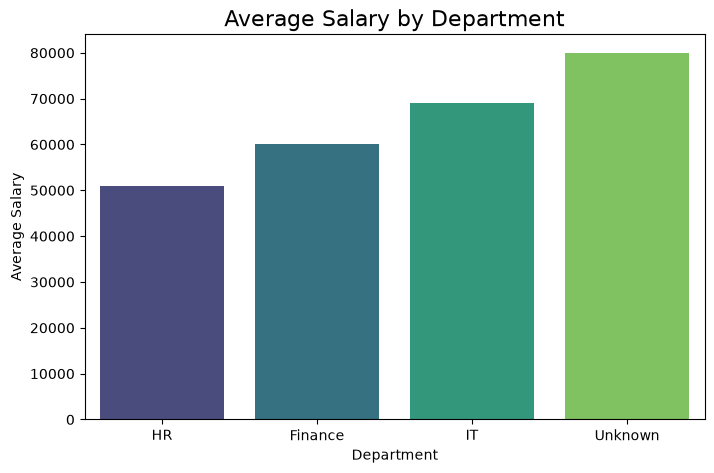

In [8]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=dept_salary,
    x="Department",
    y="Average_Salary",
    hue="Department",
    palette="viridis",
    legend=False
)

plt.title("Average Salary by Department", fontsize=16)
plt.xlabel("Department")
plt.ylabel("Average Salary")

plt.show()